In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [8]:
df = pd.read_csv("datos/datos.csv")

In [9]:
df.head()
df.describe()

,appid,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,copiessold,revenue,firstreleasedate,reviewscore
count,2.323000e+04,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,2.323000e+04,2.323000e+04,2.323000e+04,23230.000000
mean,5.916447e+05,0.294791,38.654283,357.344727,82.258674,107.152217,112.587000,5.886544,6.482484e+04,2.605762e+05,1.481585e+12,70.916746
std,2.486956e+05,2.185441,310.533420,2653.099238,729.596943,1714.138494,2066.700829,6.258438,5.067301e+05,1.087396e+06,6.529230e+10,20.940744
min,2.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,9.229428e+11,0.000000
25%,3.978025e+05,0.000000,0.000000,6.000000,2.000000,0.000000,0.000000,1.690000,5.400000e+02,5.640000e+02,1.455512e+12,59.000000
50%,5.908300e+05,0.000000,8.000000,24.000000,8.000000,0.000000,0.000000,3.990000,3.213000e+03,5.133000e+03,1.499314e+12,75.000000
75%,7.908475e+05,0.000000,23.000000,118.000000,37.000000,0.000000,0.000000,7.190000,1.898500e+04,4.965075e+04,1.527134e+12,87.000000
max,1.069460e+06,18.000000,9821.000000,292574.000000,91664.000000,190625.000000,190625.000000,154.990000,5.355018e+07,1.229418e+07,1.682482e+12,100.000000


In [10]:
df.isnull().sum()

appid                0
nombre               0
release_date         0
english              0
developer            1
publisher           12
publisherclass       0
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
copiessold           0
revenue              0
unreleased           0
earlyaccess          0
firstreleasedate     0
reviewscore          0
dtype: int64

In [11]:
print(f"Cantidad de filas antes del drop: {len(df)}")
df = df.drop_duplicates()
print(f"Cantidad de filas después del drop: {len(df)}")

Cantidad de filas antes del drop: 23230
Cantidad de filas después del drop: 23230


In [12]:
X = df.drop(columns=["copiessold"]).copy()
y = df["copiessold"].copy()

print("Dimensiones (filas, columnas):", df.shape)
df.head()


Dimensiones (filas, columnas): (23230, 25)


,appid,nombre,release_date,english,developer,publisher,publisherclass,platforms,required_age,categories,...,average_playtime,median_playtime,owners,price,copiessold,revenue,unreleased,earlyaccess,firstreleasedate,reviewscore
0,20,Team Fortress Classic,1999-04-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,...,277,62,5000000-10000000,3.99,385769,862278,False,False,922942800000,87
1,30,Day of Defeat,2003-05-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,...,187,34,5000000-10000000,3.99,234765,500723,False,False,1051761600000,90
2,40,Deathmatch Classic,2001-06-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,...,258,184,5000000-10000000,3.99,146340,312387,False,False,991368000000,83
3,50,Half-Life: Opposing Force,1999-11-01,t,Gearbox Software,Valve,AAA,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,...,624,415,5000000-10000000,3.99,815610,1641208,False,False,941432400000,95
4,60,Ricochet,2000-11-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,...,175,10,5000000-10000000,3.99,289530,619066,False,False,973054800000,83


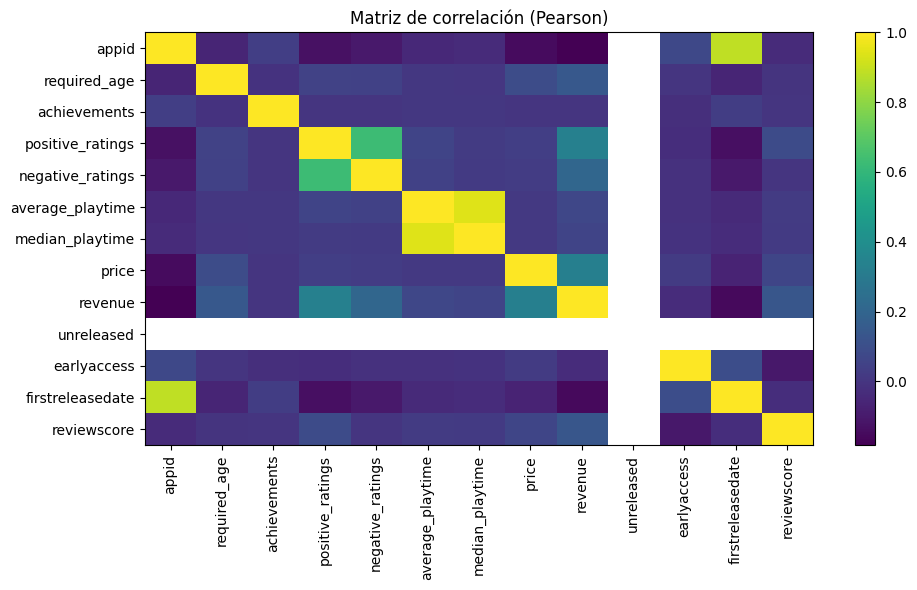

In [13]:
corr = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()


In [ ]:
encoder = OneHotEncoder(categories='auto')
data = X[["Customer_Gender", "Country", "Product_Category"]]
result = encoder.fit_transform(data).toarray()
df_cuantitativo = X.drop(columns=["Customer_Gender", "Country", "Product_Category"])

column_names = encoder.get_feature_names_out(data.columns)

data_scaled = pd.DataFrame(result, columns=column_names, index=data.index)
df_encoded = pd.concat([data_scaled, df_cuantitativo], axis=1)
df_encoded.head()
df_encoded.describe()

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer

df['genres'] = df['genres'].str.split(', ')
mlb = MultiLabelBinarizer()
generos_binarizados = mlb.fit_transform(df['genres'])

# `mlb.classes_` te muestra los géneros que encontró en orden
print(f"Géneros encontrados: {mlb.classes_}")

Géneros encontrados: ['Action' 'Action;Adventure' 'Action;Adventure;Casual' ...
 'Violent;Simulation' 'Violent;Simulation;Early Access' 'Violent;Sports']


In [20]:
df_generos = pd.DataFrame(generos_binarizados, columns=mlb.classes_)

print(df_generos)

       Action  Action;Adventure  Action;Adventure;Casual  \
0           1                 0                        0   
1           1                 0                        0   
2           1                 0                        0   
3           1                 0                        0   
4           1                 0                        0   
...       ...               ...                      ...   
23225       0                 0                        0   
23226       0                 0                        0   
23227       0                 0                        0   
23228       0                 0                        0   
23229       0                 0                        0   

       Action;Adventure;Casual;Free to Play;Indie  \
0                                               0   
1                                               0   
2                                               0   
3                                               0   
4             

In [ ]:
scaler = MinMaxScaler()
#Falta OneHotEncoder y lo que hice arriba con el multilabel (mañana lo termino antes de la reu)
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Verificamos: media ~0, std ~1
display(X_scaled.describe().loc[["mean", "std"]])

ValueError: could not convert string to float: 'Team Fortress Classic'

In [ ]:
pca = PCA()
pca.fit(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp = np.cumsum(exp_var)
k = len(exp_var)

# Varianza explicada
fig, ax = plt.subplots()
ax.bar(range(1, k+1), exp_var, label="Individual")
ax.plot(range(1, k+1), cum_exp, marker="o", label="Acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Fracción de varianza")
ax.set_title("PCA - Varianza explicada")
ax.legend()
plt.show()

# Proyección 2D
Z = pca.transform(X_scaled)
pc1, pc2 = Z[:,0], Z[:,1]

fig, ax = plt.subplots()
for c in np.unique(y):
    sel = y.values == c
    ax.scatter(pc1[sel], pc2[sel], s=35, alpha=0.8, label=f"Clase {c}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - Proyección 2D (PC1 vs PC2)")
ax.legend()
plt.show()